# Tutorial 4: Logistic Regression - Binary and 5-Class Multinomial Classification

Dataset: `placement_predict_50k.csv`

This notebook follows the same workflow as the original lab:
1. Build a preprocessing + model pipeline
2. Fit binary logistic regression for `PlacementStatus`
3. Create a 5-class target from `CGPA` and fit multinomial logistic regression
4. Evaluate accuracy and per-class performance

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

### Data loading and class balance
This cell loads the placement dataset and prints the distribution of the target variables. We inspect the class proportions before training so we can understand the dataset balance and the five-class target setup.

In [8]:
placement = pd.read_csv("placement_predict_50k.csv")
print(placement.shape)

print(placement["PlacementStatus"].value_counts(normalize=True).round(3))
print()

placement["CGPA_5Tier"] = pd.qcut(
    placement["CGPA"], q=5, labels=["Tier_1", "Tier_2", "Tier_3", "Tier_4", "Tier_5"], duplicates="drop"
)
print(placement["CGPA_5Tier"].value_counts(normalize=True).round(3))

(50000, 12)
PlacementStatus
Placed       0.699
NotPlaced    0.301
Name: proportion, dtype: float64

CGPA_5Tier
Tier_2    0.203
Tier_1    0.201
Tier_4    0.200
Tier_5    0.199
Tier_3    0.198
Name: proportion, dtype: float64


### Feature engineering setup
This cell selects the input columns and defines the preprocessing pipeline. Numeric features are standardized, while categorical features are one-hot encoded so the model can work with mixed data types.

In [9]:
numeric = ["CGPA", "Internships", "Projects", "AptitudeScore",
           "SoftSkillsRating", "Backlogs"]
categorical = ["Stream", "Gender", "PlacementTraining"]

X = placement[numeric + categorical]
y = (placement["PlacementStatus"] == "Placed").astype(int)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

### Train/validation split and binary model
This cell splits the data into training and validation sets and trains a logistic regression model for the binary placement outcome. The model learns how student attributes relate to PlacementStatus.

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

binary_model = Pipeline([
    ("prep", preprocessor),
    ("lr", LogisticRegression(max_iter=1000)),
])
binary_model.fit(X_train, y_train)

print("Baseline (always say Placed):", round(y_val.mean(), 4))
print("Model accuracy:", round(accuracy_score(y_val, binary_model.predict(X_val)), 4))

Baseline (always say Placed): 0.6987
Model accuracy: 0.8065


### Interpreting coefficients
This cell plots the coefficient values to show which features increase or decrease the chance of placement. Positive coefficients push the prediction toward the Placed class, and negative coefficients push it away.

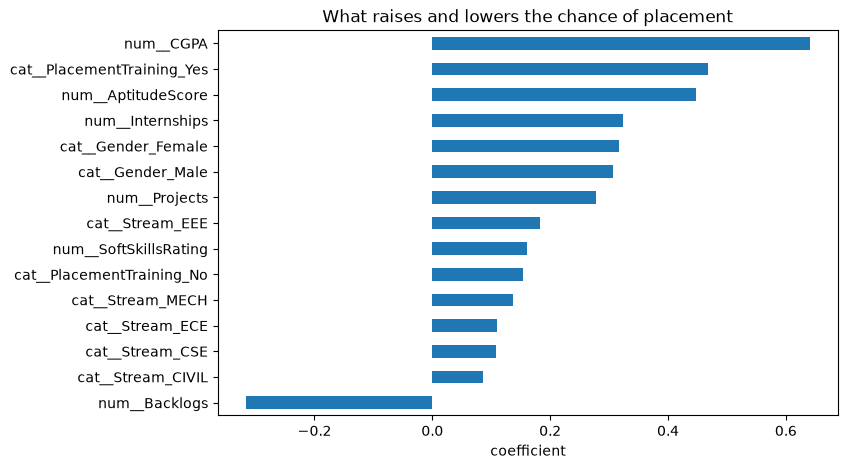

In [11]:
names = binary_model.named_steps["prep"].get_feature_names_out()
coefs = binary_model.named_steps["lr"].coef_[0]

pd.Series(coefs, index=names).sort_values().plot.barh(figsize=(8, 5))
plt.xlabel("coefficient")
plt.title("What raises and lowers the chance of placement")
plt.show()

### Five-class multinomial logistic regression
This section creates a 5-class target from `CGPA` by splitting the scores into five ordered bins. This allows us to perform multinomial logistic regression, where the model predicts one of five classes instead of just two.

In [14]:
X2 = placement[[c for c in numeric if c != "CGPA"] + categorical]
y2 = placement["CGPA_5Tier"]

print("Tier baseline (most common class share):", round(y2.value_counts(normalize=True).max(), 4))

X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

tier_model = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), [c for c in numeric if c != "CGPA"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])),
    ("lr", LogisticRegression(max_iter=1000)),
])
tier_model.fit(X2_train, y2_train)

print("Accuracy:", round(accuracy_score(y2_val, tier_model.predict(X2_val)), 4))
print("Classes:", list(tier_model.named_steps["lr"].classes_))
print("coef_ shape:", tier_model.named_steps["lr"].coef_.shape)

Tier baseline (most common class share): 0.2027
Accuracy: 0.5292
Classes: ['Tier_1', 'Tier_2', 'Tier_3', 'Tier_4', 'Tier_5']
coef_ shape: (5, 14)


### Regularization comparison
This final cell compares different values of the regularization strength `C` to see how the model changes when we encourage simpler or more flexible solutions.

In [15]:
def evaluate_classifier(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    print("Train accuracy:", round(train_acc, 4))
    print("Val accuracy:", round(val_acc, 4))
    print()
    print(classification_report(y_val, model.predict(X_val)))

    return val_acc

models = {
    "C=0.01 (strong penalty)": LogisticRegression(C=0.01, max_iter=1000),
    "C=1 (default)": LogisticRegression(C=1, max_iter=1000),
    "C=100 (weak penalty)": LogisticRegression(C=100, max_iter=1000),
}

scores = {}
for name in models:
    print("=" * 55)
    print(name)
    print("=" * 55)
    pipe = Pipeline([
        ("prep", preprocessor),
        ("lr", models[name]),
    ])
    scores[name] = evaluate_classifier(pipe, X_train, y_train, X_val, y_val)

print(pd.Series(scores).round(4))

multinomial_scores = {}
for name in models:
    print("=" * 55)
    print("Multinomial - " + name)
    print("=" * 55)
    m = Pipeline([
        ("prep", ColumnTransformer([
            ("num", StandardScaler(), [c for c in numeric if c != "CGPA"]),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ])),
        ("lr", LogisticRegression(C=models[name].C, max_iter=1000)),
    ])
    multinomial_scores[name] = evaluate_classifier(m, X2_train, y2_train, X2_val, y2_val)

print(pd.Series(multinomial_scores).round(4))

C=0.01 (strong penalty)
Train accuracy: 0.8058
Val accuracy: 0.8063

              precision    recall  f1-score   support

           0       0.72      0.58      0.64      3013
           1       0.83      0.90      0.87      6987

    accuracy                           0.81     10000
   macro avg       0.78      0.74      0.76     10000
weighted avg       0.80      0.81      0.80     10000

C=1 (default)
Train accuracy: 0.8053
Val accuracy: 0.8065

              precision    recall  f1-score   support

           0       0.72      0.58      0.65      3013
           1       0.83      0.90      0.87      6987

    accuracy                           0.81     10000
   macro avg       0.78      0.74      0.76     10000
weighted avg       0.80      0.81      0.80     10000

C=100 (weak penalty)
Train accuracy: 0.8053
Val accuracy: 0.8065

              precision    recall  f1-score   support

           0       0.72      0.58      0.65      3013
           1       0.83      0.90      0.87